<a href="https://colab.research.google.com/github/joannapeniket/pet-classifier/blob/main/pet_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pet Breed Classifier — Transfer Learning with ResNet18  

Fine-grained image classification over the 37 cat and dog breeds of the
[Oxford-IIIT Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/) dataset, using
an ImageNet-pretrained ResNet18 as a frozen feature extractor with a
newly-trained classification head.

**Approach**

| | |
|---|---|
| Backbone | ResNet18, ImageNet-pretrained, frozen |
| Head | Single `Linear(512, 37)`, trained from scratch |
| Trainable parameters | ~19k of 11.7M (0.16%) |
| Data | 3,680 `trainval` images split 85/15 into train/val; 3,669 held-out test images |
| Augmentation | Random resized crop + horizontal flip (training split only) |
| Optimiser | Adam, lr 1e-3, cross-entropy loss, 10 epochs |

Runs end to end on a free Colab T4 GPU in a few minutes.
`Runtime -> Change runtime type -> T4 GPU` before running.


## Setup

In [1]:
import os
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")


torch 2.11.0+cpu | device: cpu


Configuration in one place, so every run is reproducible and easy to vary.

In [2]:
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
VAL_FRACTION = 0.15
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

# ImageNet channel statistics — required, since the backbone was pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

torch.manual_seed(SEED)
random.seed(SEED)


## 1. Data

Two transform pipelines: a randomised one for training (augmentation gives
more effective variety out of a small dataset) and a deterministic one for
validation and test (so reported accuracy reflects the model, not the luck of
a random crop). Both end in ImageNet normalisation, which the pretrained
backbone requires.


In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


Oxford-IIIT Pet ships only `trainval` and `test` splits, so the validation
set is carved out here. The dataset is instantiated twice over the same
`trainval` images — once per transform — and a single seeded index
permutation is applied to both, so the training subset is augmented and the
validation subset is not, without any overlap between them.


In [4]:
trainval_augmented = datasets.OxfordIIITPet(
    root="./data", split="trainval", download=True, transform=train_transform
)
trainval_clean = datasets.OxfordIIITPet(
    root="./data", split="trainval", download=True, transform=eval_transform
)
test_dataset = datasets.OxfordIIITPet(
    root="./data", split="test", download=True, transform=eval_transform
)

class_names = trainval_augmented.classes
num_classes = len(class_names)

n_total = len(trainval_augmented)
n_val = int(VAL_FRACTION * n_total)

generator = torch.Generator().manual_seed(SEED)
shuffled = torch.randperm(n_total, generator=generator).tolist()

train_dataset = Subset(trainval_augmented, shuffled[: n_total - n_val])
val_dataset = Subset(trainval_clean, shuffled[n_total - n_val :])

print(f"{num_classes} classes")
print(f"train {len(train_dataset)} | val {len(val_dataset)} | test {len(test_dataset)}")


100%|██████████| 792M/792M [00:31<00:00, 24.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.84MB/s]


37 classes
train 3128 | val 552 | test 3669


In [5]:
# Shuffle only the training split; val/test stay in fixed order for reproducible metrics
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


A look at one training batch, to confirm images and labels line up and augmentation is active.

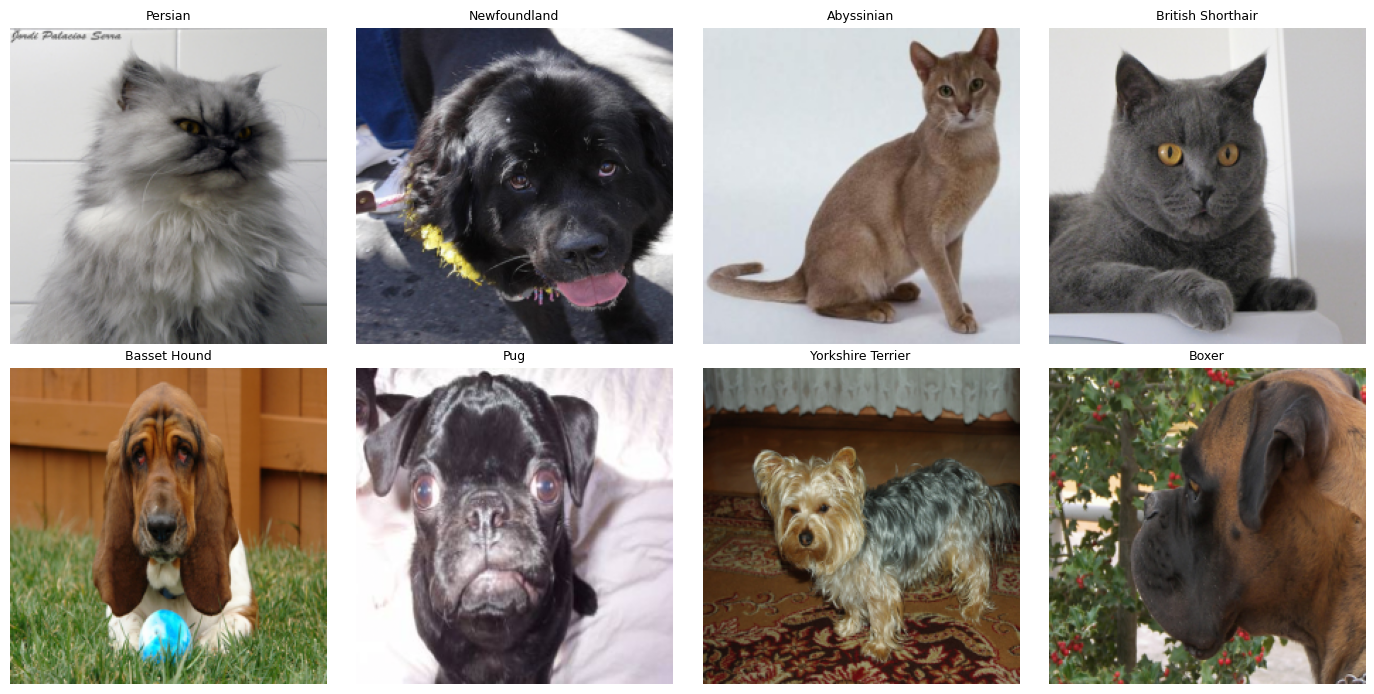

In [6]:
def denormalize(img_tensor):
    """Undo ImageNet normalisation, for display only."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img_tensor * std + mean


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Model

The pretrained backbone is frozen and its 1000-class ImageNet head is
replaced with a fresh `Linear` layer sized to the 37 breeds. Only that head
is trainable, which is what makes this trainable in minutes on ~3k images.


In [7]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)  # new layers are trainable by default
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total     {total_params:,}")
print(f"trainable {trainable_params:,} ({trainable_params / total_params:.2%})")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s]

total     11,195,493
trainable 18,981 (0.17%)


## 3. Training

The optimiser is given only `model.fc.parameters()`, so the frozen backbone
cannot be updated even if `requires_grad` were set differently — a second,
independent guarantee on top of the freeze.


In [8]:
criterion = nn.CrossEntropyLoss()  # expects raw logits; no softmax in the model
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        running_loss += criterion(outputs, labels).item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [9]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    for key, value in zip(history, (train_loss, train_acc, val_loss, val_acc)):
        history[key].append(value)

    print(f"epoch {epoch + 1:2d}/{NUM_EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f}")


epoch  1/10 | train loss 2.0622 acc 0.5329 | val loss 0.9698 acc 0.8007
epoch  2/10 | train loss 0.7836 acc 0.8549 | val loss 0.6126 acc 0.8406
epoch  3/10 | train loss 0.5302 acc 0.8958 | val loss 0.4882 acc 0.8569
epoch  4/10 | train loss 0.4156 acc 0.9114 | val loss 0.4389 acc 0.8768
epoch  5/10 | train loss 0.3526 acc 0.9153 | val loss 0.3987 acc 0.8841
epoch  6/10 | train loss 0.3024 acc 0.9364 | val loss 0.3684 acc 0.8877
epoch  7/10 | train loss 0.2769 acc 0.9345 | val loss 0.3699 acc 0.8859
epoch  8/10 | train loss 0.2536 acc 0.9421 | val loss 0.3450 acc 0.8877
epoch  9/10 | train loss 0.2250 acc 0.9482 | val loss 0.3341 acc 0.9022
epoch 10/10 | train loss 0.2081 acc 0.9504 | val loss 0.3266 acc 0.9022


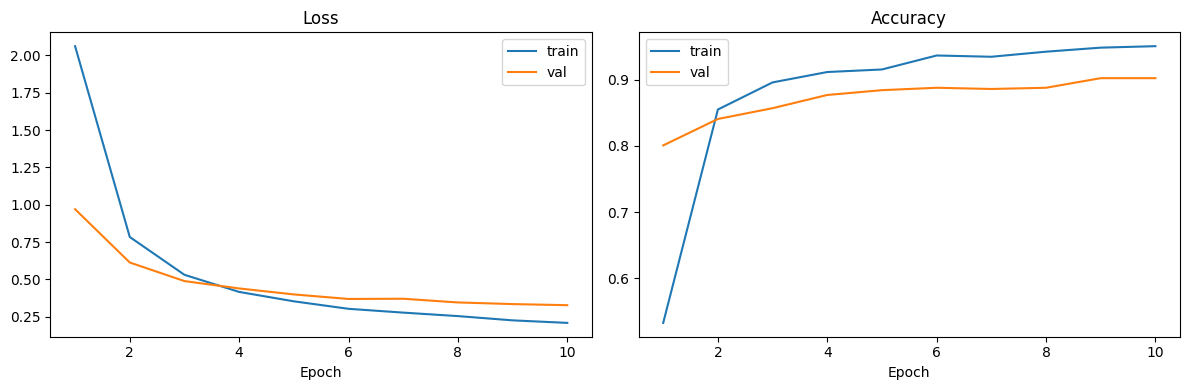

In [10]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(axes, ("loss", "acc"), ("Loss", "Accuracy")):
    ax.plot(epochs_range, history[f"train_{metric}"], label="train")
    ax.plot(epochs_range, history[f"val_{metric}"], label="val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()


## 4. Evaluation

The test split has not been used for training or for any tuning decision, so
this is an unbiased estimate of performance.


In [11]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test accuracy: {test_acc * 100:.1f}%  (loss {test_loss:.4f})")


Test accuracy: 87.9%  (loss 0.3950)


Sample predictions, green where correct and red where wrong. Images are drawn
at random rather than taken from the first batch, since the test split is
ordered by breed and a sequential batch would show almost one class.


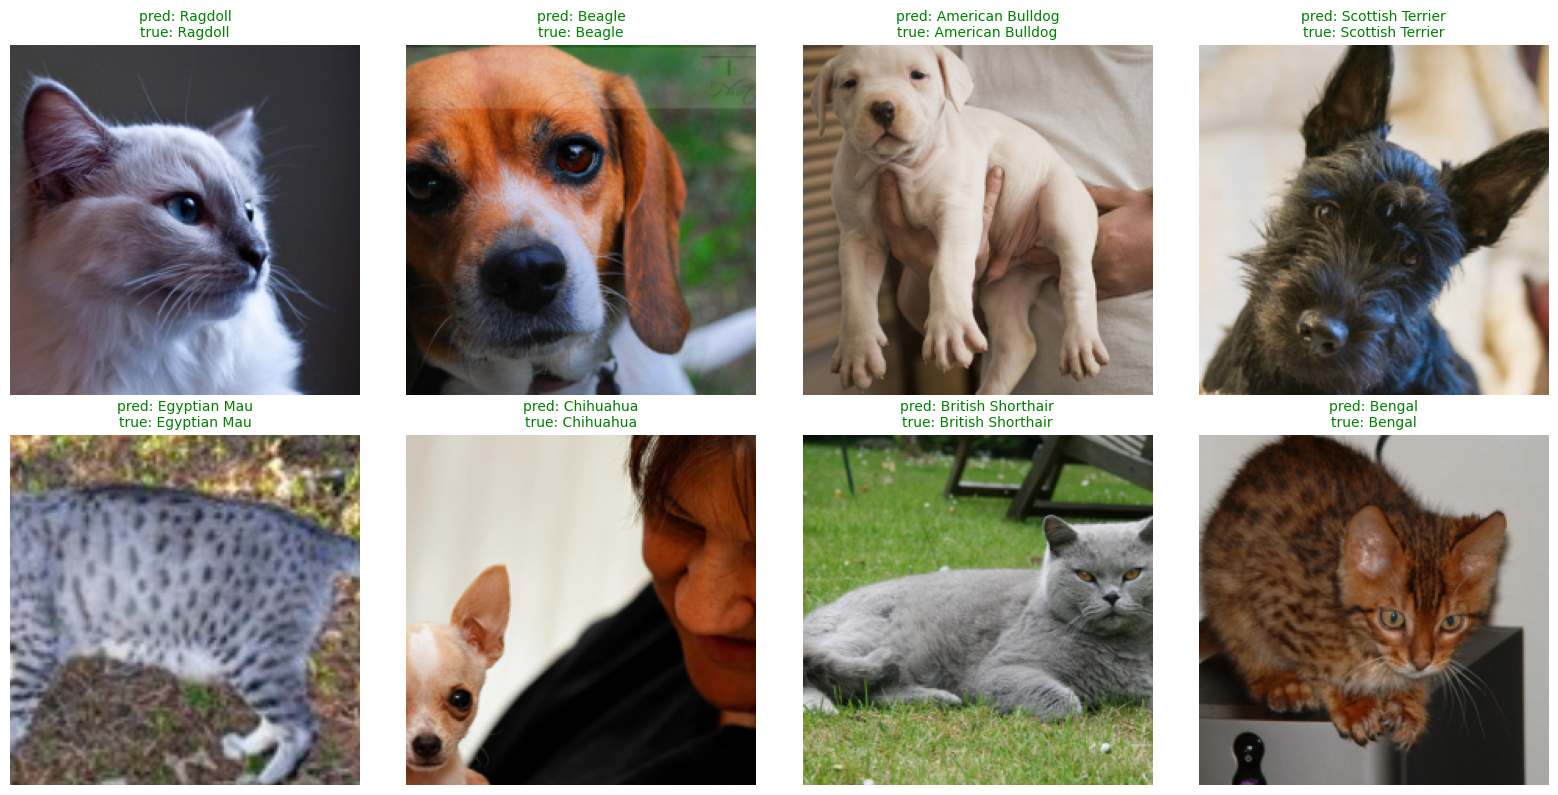

In [12]:
sample_indices = random.sample(range(len(test_dataset)), 8)
sample_images = torch.stack([test_dataset[i][0] for i in sample_indices])
sample_labels = torch.tensor([test_dataset[i][1] for i in sample_indices])

model.eval()
with torch.no_grad():
    sample_preds = model(sample_images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(sample_images[i]).permute(1, 2, 0).clamp(0, 1).numpy())
    correct = sample_preds[i] == sample_labels[i]
    ax.set_title(
        f"pred: {class_names[sample_preds[i]]}\ntrue: {class_names[sample_labels[i]]}",
        color="green" if correct else "red", fontsize=10,
    )
    ax.axis("off")

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/predictions.png", dpi=150, bbox_inches="tight")
plt.show()


Which breeds does it confuse? The diagonal of the confusion matrix is correct
predictions; the largest off-diagonal entries are the model's characteristic
mistakes.


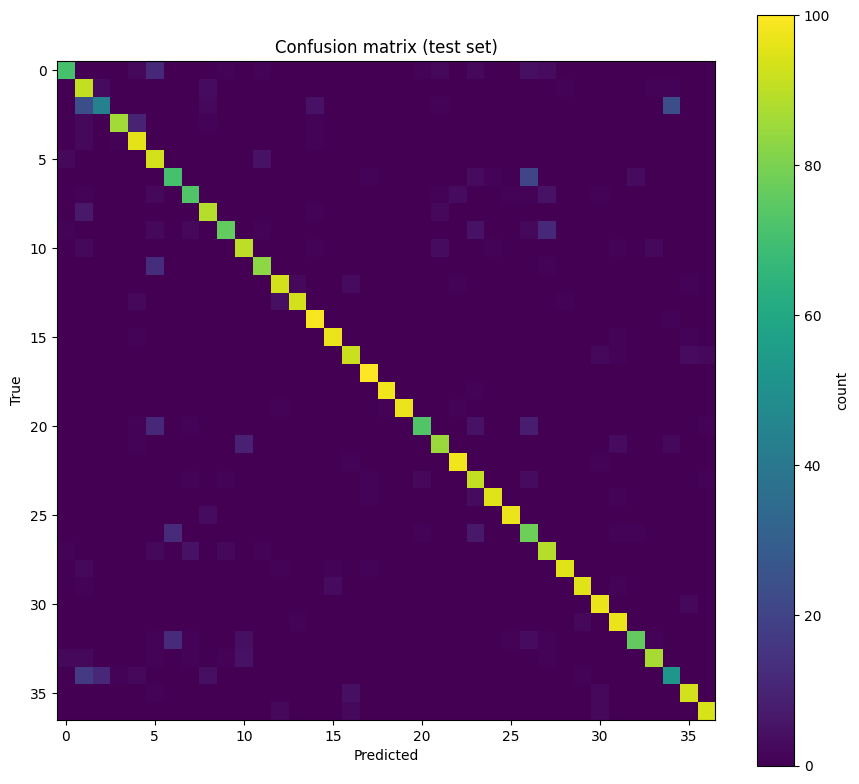

In [13]:
conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(dim=1).cpu()
        for true_label, pred_label in zip(labels, preds):
            conf_matrix[true_label, pred_label] += 1

plt.figure(figsize=(9, 8))
plt.imshow(conf_matrix, cmap="viridis")
plt.colorbar(label="count")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()


In [14]:
off_diagonal = conf_matrix.clone()
off_diagonal.fill_diagonal_(0)
top_confusions = torch.topk(off_diagonal.flatten(), 8)

print("Most-confused pairs (true -> predicted):\n")
for count, flat_index in zip(top_confusions.values, top_confusions.indices):
    true_idx, pred_idx = divmod(flat_index.item(), num_classes)
    print(f"  {class_names[true_idx]:<28} -> {class_names[pred_idx]:<28} {count.item()}")


Most-confused pairs (true -> predicted):

  American Pit Bull Terrier    -> American Bulldog             24
  American Pit Bull Terrier    -> Staffordshire Bull Terrier   24
  Birman                       -> Ragdoll                      21
  Staffordshire Bull Terrier   -> American Bulldog             17
  Egyptian Mau                 -> Bengal                       13
  Siamese                      -> Birman                       12
  Ragdoll                      -> Birman                       12
  Maine Coon                   -> Bengal                       11


## 5. Representation analysis

How much of the accuracy comes from the pretrained representation itself,
rather than from the trained head? A nearest-centroid classifier answers
this: each breed is represented by the mean embedding of its training images,
and test images are assigned to the closest centroid — no learned parameters
at all.

The trained head is expected to win; the size of the gap is the result. A
small gap means the frozen backbone already clusters the breeds and the head
is largely reading off existing structure.

Run before fine-tuning, so the measurement describes the frozen pretrained
representation.


Swapping the head for `nn.Identity()` turns the classifier into a feature
extractor. Training embeddings are taken from the non-augmented view, so
centroids describe breeds rather than crops.


In [15]:
import torch.nn.functional as F

# Training features come from the CLEAN view of the training images, not the
# augmented one — centroids should describe the breeds, not random crops.
train_clean_subset = Subset(trainval_clean, shuffled[: n_total - n_val])
train_clean_loader = DataLoader(train_clean_subset, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2)


@torch.no_grad()
def extract_features(model, loader, device):
    """Run images through the backbone only, returning 512-d embeddings."""
    model.eval()
    features, labels = [], []
    for images, batch_labels in loader:
        features.append(model(images.to(device)).cpu())
        labels.append(batch_labels)
    return torch.cat(features), torch.cat(labels)


# Temporarily replace the classifier head with a pass-through, so the model
# outputs the 512-d feature vector instead of 37 class scores.
saved_head = model.fc
model.fc = nn.Identity()

train_features, train_feature_labels = extract_features(model, train_clean_loader, device)
test_features, test_feature_labels = extract_features(model, test_loader, device)

model.fc = saved_head  # restore, so the rest of the notebook still works

print(f"train features: {tuple(train_features.shape)}")
print(f"test features:  {tuple(test_features.shape)}")


train features: (3128, 512)
test features:  (3669, 512)


Two distance choices, since the metric is an assumption rather than a given:
cosine compares direction only, Euclidean also accounts for magnitude. Where
they disagree, the embedding space carries information in vector length as
well as direction.


In [16]:
# One centroid per breed: the mean embedding of that breed's training images
centroids = torch.stack([
    train_features[train_feature_labels == c].mean(dim=0)
    for c in range(num_classes)
])

# Cosine: compare directions only, ignoring vector length
cosine_similarities = F.normalize(test_features, dim=1) @ F.normalize(centroids, dim=1).T
cosine_preds = cosine_similarities.argmax(dim=1)
cosine_acc = (cosine_preds == test_feature_labels).float().mean().item()

# Euclidean: straight-line distance in the 512-d space
euclidean_preds = torch.cdist(test_features, centroids).argmin(dim=1)
euclidean_acc = (euclidean_preds == test_feature_labels).float().mean().item()

print(f"centroids: {tuple(centroids.shape)}\n")
print(f"nearest centroid, cosine:     {cosine_acc * 100:.1f}%")
print(f"nearest centroid, euclidean:  {euclidean_acc * 100:.1f}%")
print(f"trained linear head:          {test_acc * 100:.1f}%")
print(f"\ngap (head - best centroid):   "
      f"{(test_acc - max(cosine_acc, euclidean_acc)) * 100:+.1f} pp")


centroids: (37, 512)

nearest centroid, cosine:     87.0%
nearest centroid, euclidean:  86.6%
trained linear head:          87.9%

gap (head - best centroid):   +0.9 pp


Cross-referencing the confusion matrix against centroid geometry: if the
representation is well-behaved, the breeds the model confuses should be the
breeds whose centroids sit closest together.


In [17]:
# How similar is each pair of class centroids?
centroid_similarity = F.normalize(centroids, dim=1) @ F.normalize(centroids, dim=1).T

off_diagonal = ~torch.eye(num_classes, dtype=torch.bool)
confusion_counts = conf_matrix[off_diagonal].float()
pair_similarity = centroid_similarity[off_diagonal]

# Guard: if the model made no mistakes at all there is no variance to correlate
if confusion_counts.var() > 0 and pair_similarity.var() > 0:
    correlation = torch.corrcoef(torch.stack([confusion_counts, pair_similarity]))[0, 1]
    print(f"correlation(confusions, centroid similarity): {correlation:+.3f}\n")
else:
    print("Not enough confusions to correlate.\n")

# Do the most-confused pairs actually have the closest centroids?
top_pairs = torch.topk(conf_matrix.clone().fill_diagonal_(0).flatten(), 5)

print(f"{'true -> predicted':<58} {'count':>6} {'centroid sim':>13}")
for count, flat_index in zip(top_pairs.values, top_pairs.indices):
    i, j = divmod(flat_index.item(), num_classes)
    pair = f"{class_names[i]} -> {class_names[j]}"
    print(f"{pair:<58} {count.item():>6} {centroid_similarity[i, j]:>13.3f}")

# For contrast: the average similarity across all breed pairs
print(f"\nmean centroid similarity over all pairs: {pair_similarity.mean():.3f}")


correlation(confusions, centroid similarity): +0.413

true -> predicted                                           count  centroid sim
American Pit Bull Terrier -> Staffordshire Bull Terrier        24         0.939
American Pit Bull Terrier -> American Bulldog                  24         0.921
Birman -> Ragdoll                                              21         0.958
Staffordshire Bull Terrier -> American Bulldog                 17         0.917
Egyptian Mau -> Bengal                                         13         0.971

mean centroid similarity over all pairs: 0.770


Nearest-centroid classification on learned embeddings underpins Prototypical
Networks in few-shot learning and class-incremental methods that add classes
without retraining, and k-NN/centroid probes are standard for evaluating
self-supervised representations — it measures the representation rather than
the classifier, which is what makes it a useful diagnostic here.


## 6. Fine-tuning the last block

With the head trained, the last residual block (`layer4` — the deepest and
most ImageNet-specific part of the backbone) is unfrozen and trained at a
learning rate an order of magnitude lower than the head's, so its pretrained
weights are nudged rather than overwritten. Earlier layers stay frozen: they
encode generic edge and texture detectors that need no adaptation.

Model selection is done on validation accuracy; test is read once at the end.


In [18]:
for param in model.layer4.parameters():
    param.requires_grad = True

finetune_optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": LEARNING_RATE / 10},
    {"params": model.fc.parameters(), "lr": LEARNING_RATE},
])

FINETUNE_EPOCHS = 3

for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, finetune_optimizer, device
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"fine-tune epoch {epoch + 1}/{FINETUNE_EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f}")


fine-tune epoch 1/3 | train loss 0.2590 acc 0.9191 | val loss 0.3511 acc 0.8786
fine-tune epoch 2/3 | train loss 0.0993 acc 0.9706 | val loss 0.2948 acc 0.9130
fine-tune epoch 3/3 | train loss 0.0532 acc 0.9885 | val loss 0.2416 acc 0.9149


In [19]:
finetuned_test_loss, finetuned_test_acc = evaluate(model, test_loader, criterion, device)

print(f"frozen backbone:    {test_acc * 100:.1f}%")
print(f"after fine-tuning:  {finetuned_test_acc * 100:.1f}%")
print(f"change:             {(finetuned_test_acc - test_acc) * 100:+.1f} pp")


frozen backbone:    87.9%
after fine-tuning:  88.2%
change:             +0.3 pp
